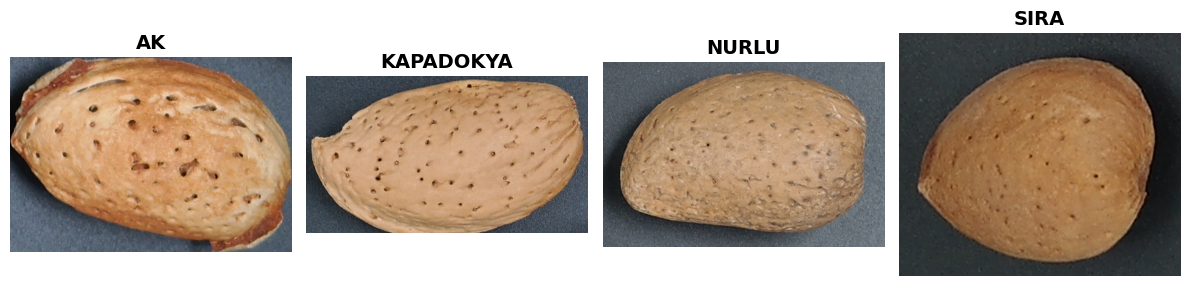

In [12]:
import matplotlib.pyplot as plt
import os

# Paths de los directorios que contienen las imágenes
almendra_ak = './Almendras/Almendras/AK/'
almendra_kapadoyka = './Almendras/Almendras/KAPADOKYA/'
almendra_nurlu = './Almendras/Almendras/NURLU/'
almendra_sira = './Almendras/Almendras/SIRA/'

# Lista de tipos de almendras y sus nombres
tipos_almendras = [
    (almendra_ak, "AK"),
    (almendra_kapadoyka, "KAPADOKYA"),
    (almendra_nurlu, "NURLU"),
    (almendra_sira, "SIRA")
]

# Crear figura y ejes para la grilla 1x4
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

# Iterar sobre cada tipo de almendra y mostrar una imagen
for col, (path, nombre) in enumerate(tipos_almendras):
    imagenes = os.listdir(path)[:1]  # Tomar solo la primera imagen
    img_path = os.path.join(path, imagenes[0])
    img = plt.imread(img_path)
    axes[col].imshow(img)
    axes[col].axis('off')
    # Poner el título encima de la columna
    axes[col].set_title(nombre, fontsize=14, fontweight='bold')

# Ajustar el diseño y mostrar la grilla
plt.tight_layout()
plt.show()

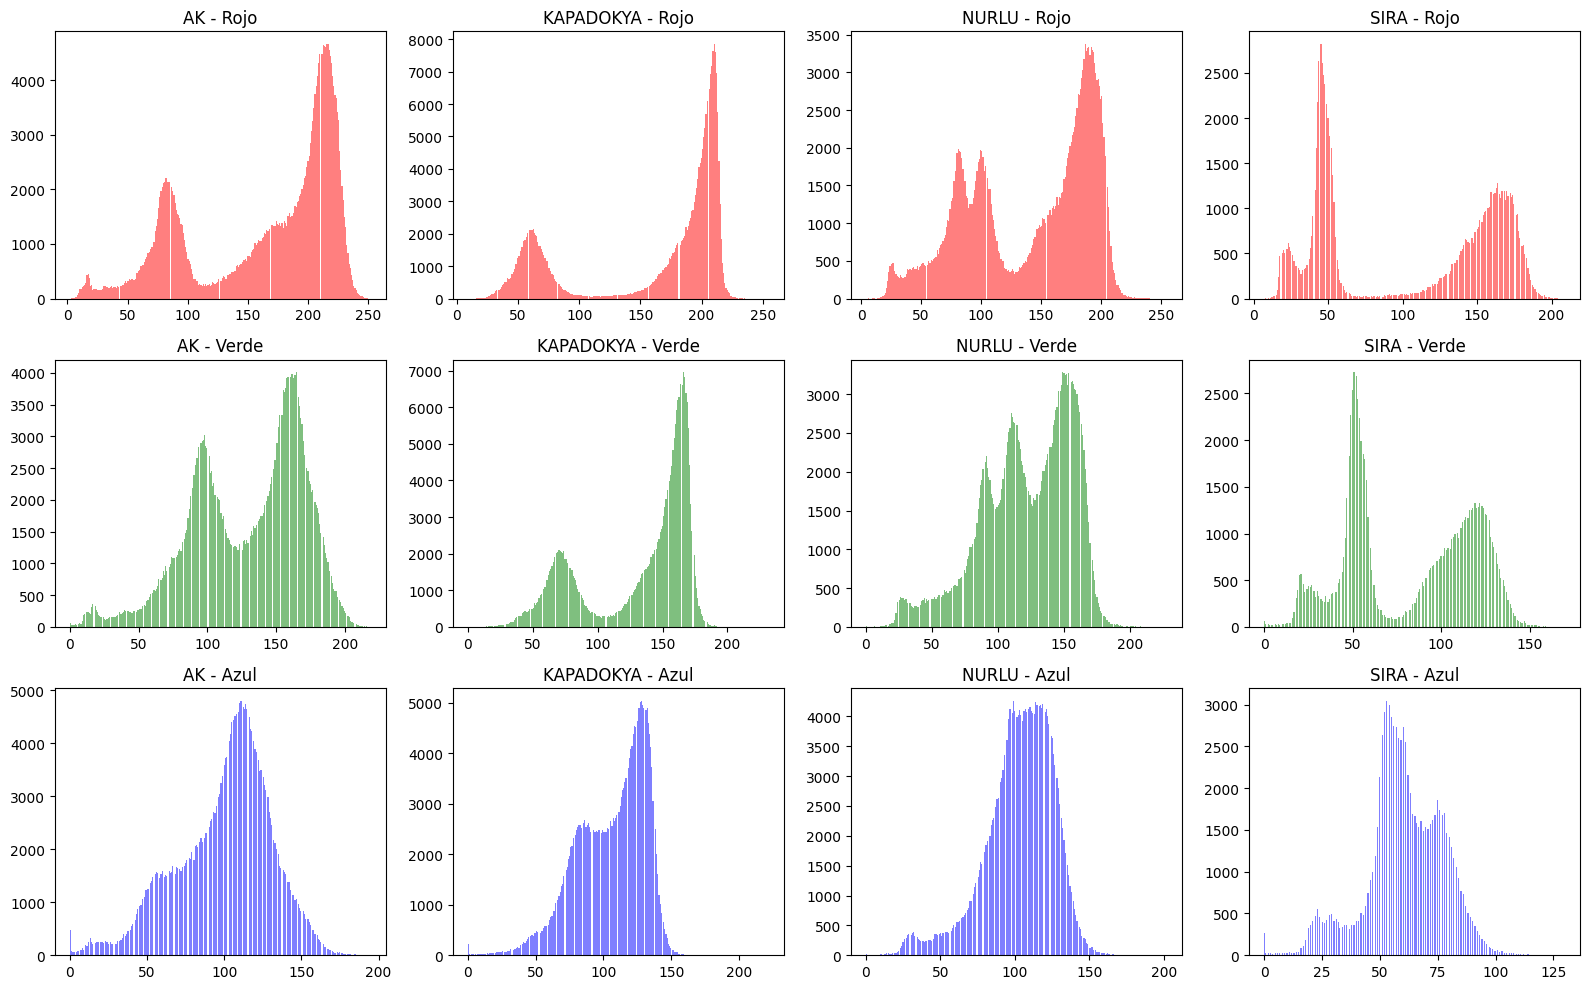

In [15]:
# Crear figura y ejes para la grilla 3x4
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.reshape(3, 4)

# Iterar sobre cada tipo de almendra y mostrar histogramas
for col, (path, nombre) in enumerate(tipos_almendras):
    imagenes = os.listdir(path)[:1]  # Tomar solo la primera imagen
    img_path = os.path.join(path, imagenes[0])
    img = plt.imread(img_path)

    # Canal Rojo
    axes[0, col].hist(img[:, :, 0].flatten(), bins=256, color='red', alpha=0.5)
    axes[0, col].set_title(f'{nombre} - Rojo')
    
    # Canal Verde
    axes[1, col].hist(img[:, :, 1].flatten(), bins=256, color='green', alpha=0.5)
    axes[1, col].set_title(f'{nombre} - Verde')
    
    # Canal Azul
    axes[2, col].hist(img[:, :, 2].flatten(), bins=256, color='blue', alpha=0.5)
    axes[2, col].set_title(f'{nombre} - Azul')

# Ajustar diseño
plt.tight_layout()
plt.show()


Ahora necesitamos saber si nuestras imagenes necesitan un realce de contraste de imagen, brillo y umbralizacion. 

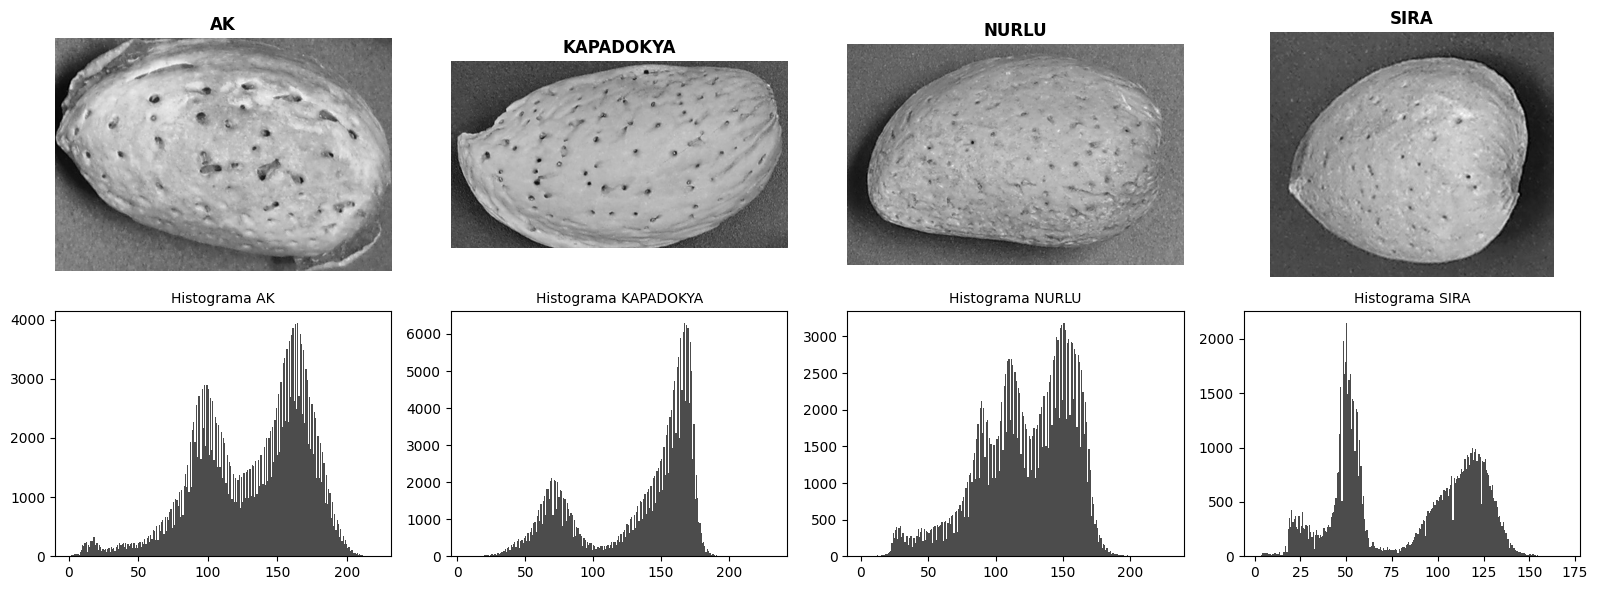

In [ ]:
""" convertimos a escala de grises y mostramos la grilla 1x4
osea necesito saber si las imagenes necesitan ajustar el contraste o no
para eso se puede usar el histograma de la imagen en escala de grises
si el histograma muestra que la mayoría de los píxeles están concentrados en un rango 
estrecho, entonces la imagen podría beneficiarse de un ajuste de contraste
"""
# histograma de blanco y negro
import numpy as np

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for col, (path, nombre) in enumerate(tipos_almendras):
    imagenes = os.listdir(path)[:1]  # Tomar solo la primera imagen
    img_path = os.path.join(path, imagenes[0])
    img = plt.imread(img_path)

    # Convertir a escala de grises (promedio de canales)
    if img.ndim == 3:  # Imagen a color
        gray = np.mean(img[:, :, :3], axis=2)
    else:  # Ya está en escala de grises
        gray = img

    # Mostrar imagen en escala de grises
    axes[0, col].imshow(gray, cmap='gray')
    axes[0, col].axis('off')
    axes[0, col].set_title(nombre, fontsize=12, fontweight='bold')

    # Mostrar histograma de la imagen en escala de grises
    axes[1, col].hist(gray.flatten(), bins=256, color='black', alpha=0.7)
    axes[1, col].set_title(f'Histograma {nombre}', fontsize=10)

plt.tight_layout()
plt.show()


### Filtrado Promedio

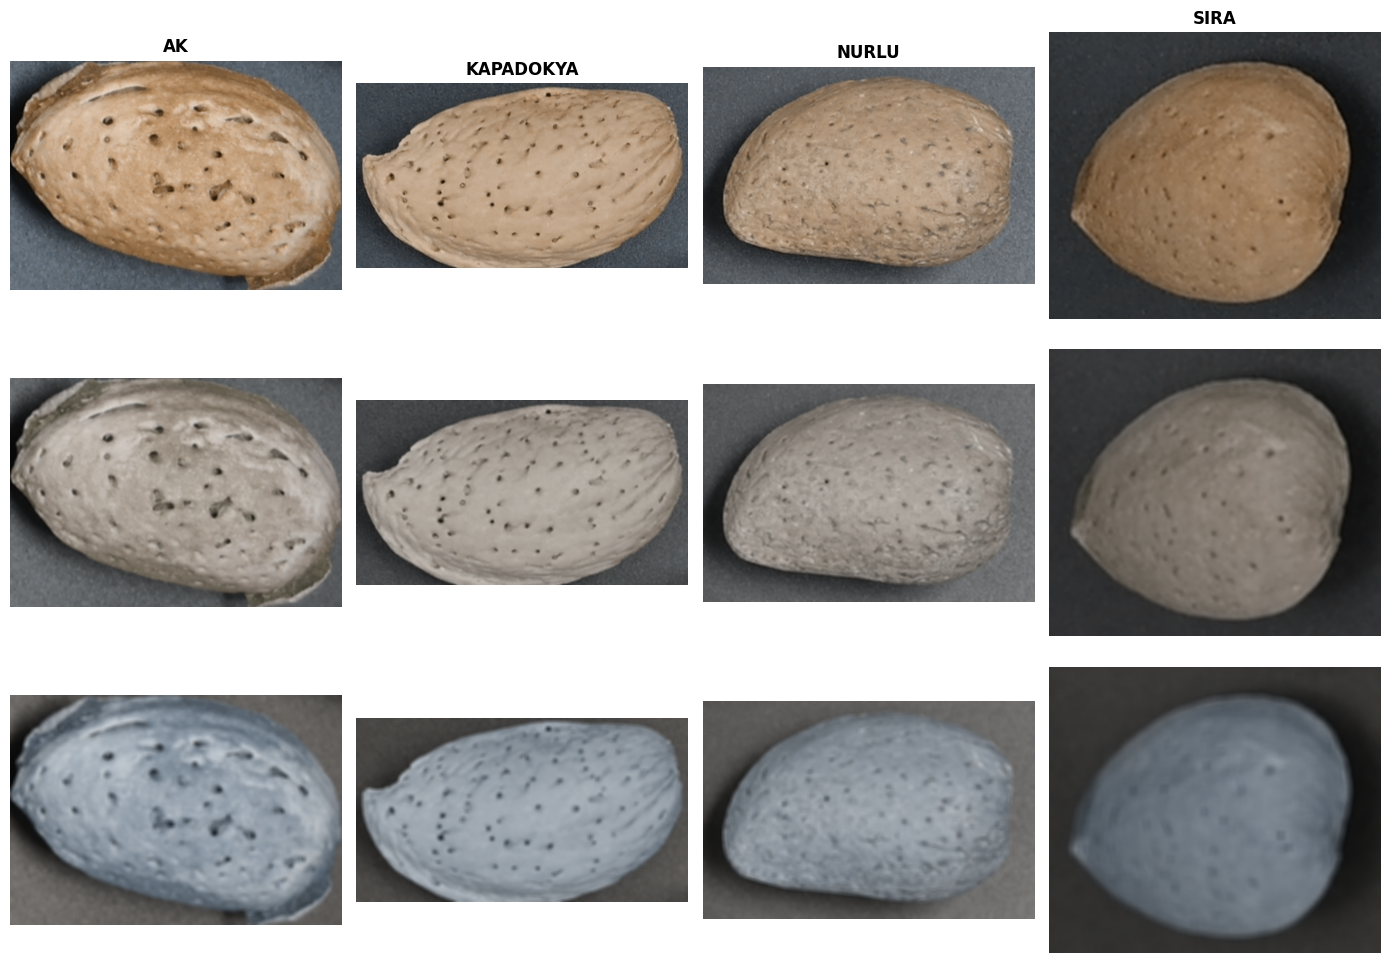

In [30]:
# primero sacaremos un filtrado promedio de cada una de las imágenes para suavizarlas
# mostramos el resultado en una grilla 3x4
# porque serian filtrado promedio 3x3, 5x5 y 9x9 de cada imagen

import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.ndimage import uniform_filter

# Tamaños de los filtros promedio
filtros = [3, 5, 9]

# Crear figura y ejes para la grilla 3x4
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.reshape(3, 4)

# Iterar sobre cada tipo de almendra y aplicar filtros
for col, (path, nombre) in enumerate(tipos_almendras):
    imagenes = os.listdir(path)[:1]  # Tomar solo la primera imagen
    img_path = os.path.join(path, imagenes[0])
    img = plt.imread(img_path)

    # Si la imagen tiene canal alfa, lo eliminamos
    if img.shape[-1] == 4:
        img = img[:, :, :3]

    # Aplicar cada filtro promedio
    for row, size in enumerate(filtros):
        filtrada = uniform_filter(img, size=size)
        axes[row, col].imshow(filtrada.astype(np.uint8))
        axes[row, col].axis('off')
        # Título en la primera fila con el nombre de la almendra
        if row == 0:
            axes[row, col].set_title(nombre, fontsize=12, fontweight='bold')
        # Etiqueta de fila con el nombre del filtro (solo en la primera columna)
        if col == 0:
            axes[row, col].set_ylabel(f'Filtro promedio {size}x{size}', fontsize=11, fontweight='bold', color='red')

# Ajustar diseño
plt.tight_layout()
plt.show()


### Mejorar la Nitidez

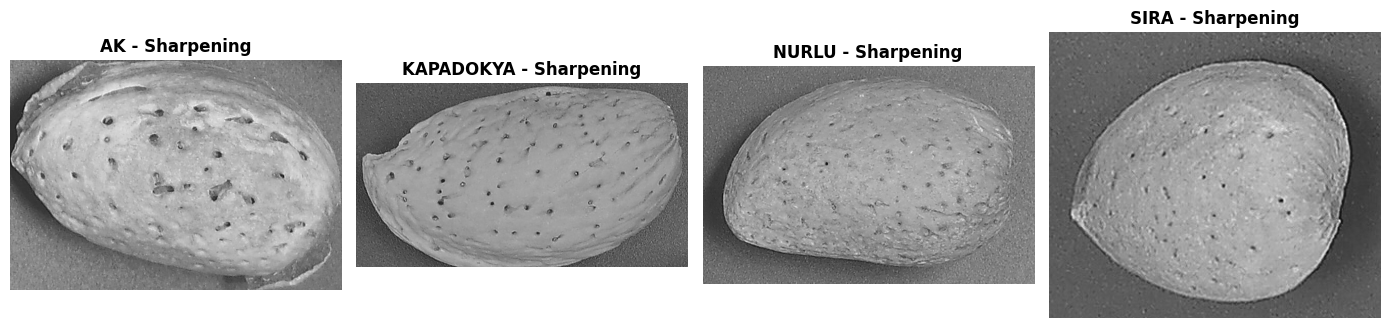

In [33]:
# para mejorar la nitidez o sharpening 

# Crear figura y ejes para la grilla 1x4
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for col, (path, nombre) in enumerate(tipos_almendras):
    imagenes = os.listdir(path)[:1]  # Tomar solo la primera imagen
    img_path = os.path.join(path, imagenes[0])
    img = plt.imread(img_path).astype(float)

    # Convertir a escala de grises
    if img.ndim == 3:
        gray = np.mean(img[:, :, :3], axis=2)
    else:
        gray = img

    # Filtrado promedio 5x5
    gray_avg5 = uniform_filter(gray, size=5)

    # Sharpening: 2*I - I_avg
    gray_sharp = 2*gray - gray_avg5

    # Normalizar al rango [0,255]
    gray_sharp_norm = (gray_sharp - gray_sharp.min()) / (gray_sharp.max() - gray_sharp.min()) * 255
    gray_sharp_norm = gray_sharp_norm.astype(np.uint8)

    # Mostrar resultado en escala de grises
    axes[col].imshow(gray_sharp_norm, cmap='gray')
    axes[col].axis('off')
    axes[col].set_title(f'{nombre} - Sharpening', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()




Filtro de mediana

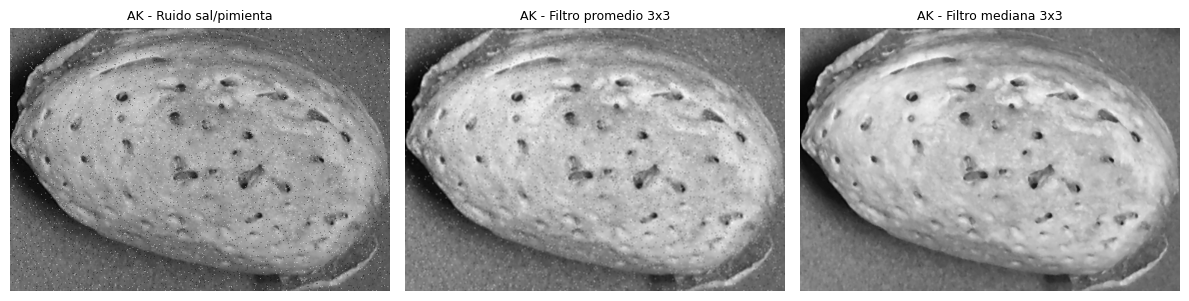

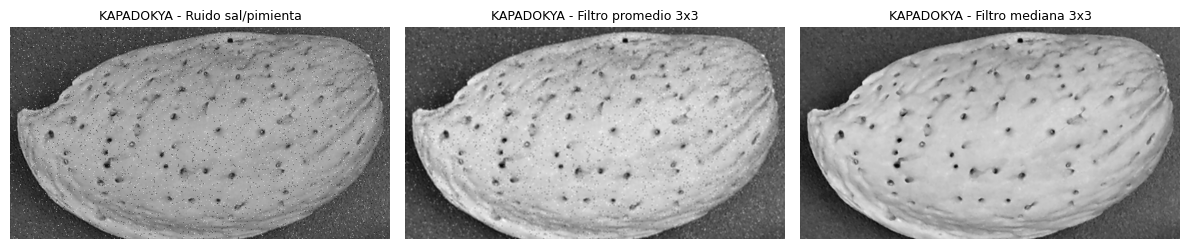

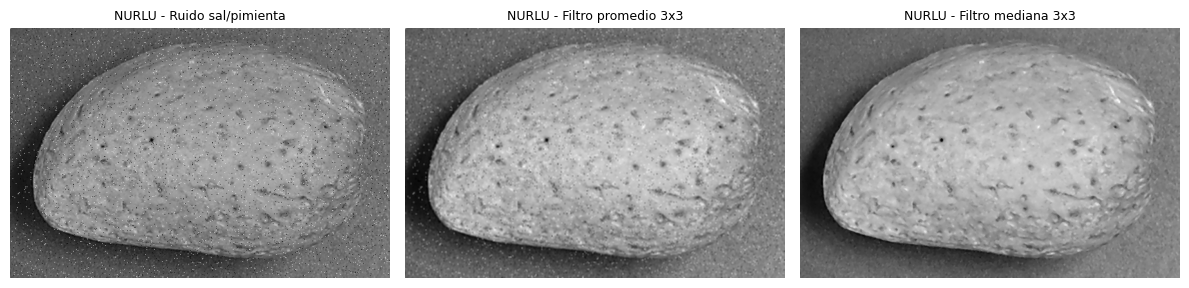

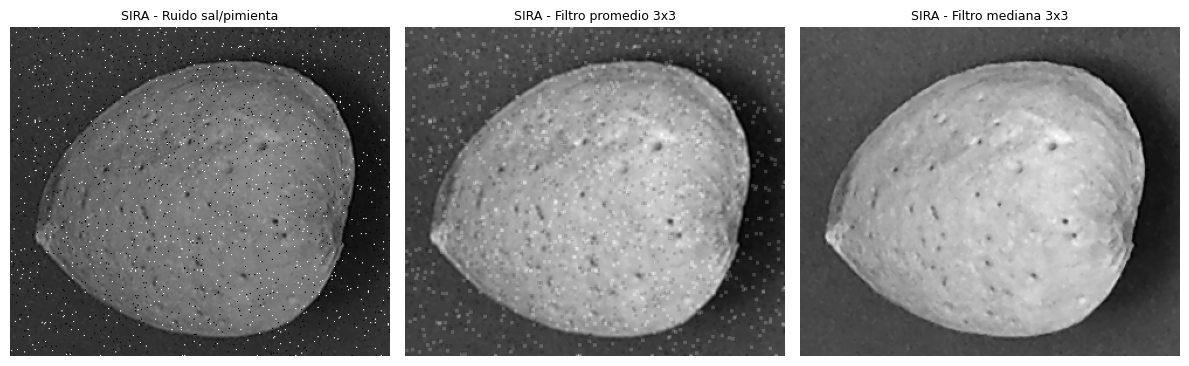

In [37]:
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.ndimage import uniform_filter, median_filter

# Función para añadir ruido sal y pimienta
def salt_pepper_noise(img, prob=0.02):
    noisy = img.copy()
    rnd = np.random.rand(*img.shape)
    noisy[rnd < prob/2] = 0       # sal (negro)
    noisy[rnd > 1 - prob/2] = 255 # pimienta (blanco)
    return noisy


# Iterar sobre cada tipo de almendra
for path, nombre in tipos_almendras:
    imagenes = os.listdir(path)[:1]  # Tomar solo la primera imagen
    img_path = os.path.join(path, imagenes[0])
    img = plt.imread(img_path)

    # Convertir a escala de grises
    if img.ndim == 3:
        gray = np.mean(img[:, :, :3], axis=2)
    else:
        gray = img

    # Añadir ruido sal y pimienta
    noisy = salt_pepper_noise(gray, prob=0.02)

    # Filtro promedio 3x3
    avg3 = uniform_filter(noisy, size=3)

    # Filtro de mediana 3x3
    med3 = median_filter(noisy, size=3)

    # Mostrar resultados en grilla 1x3
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(noisy, cmap='gray')
    axes[0].set_title(f'{nombre} - Ruido sal/pimienta', fontsize=9)
    axes[0].axis('off')

    axes[1].imshow(avg3, cmap='gray')
    axes[1].set_title(f'{nombre} - Filtro promedio 3x3', fontsize=9)
    axes[1].axis('off')

    axes[2].imshow(med3, cmap='gray')
    axes[2].set_title(f'{nombre} - Filtro mediana 3x3', fontsize=9)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

Filtro sobel

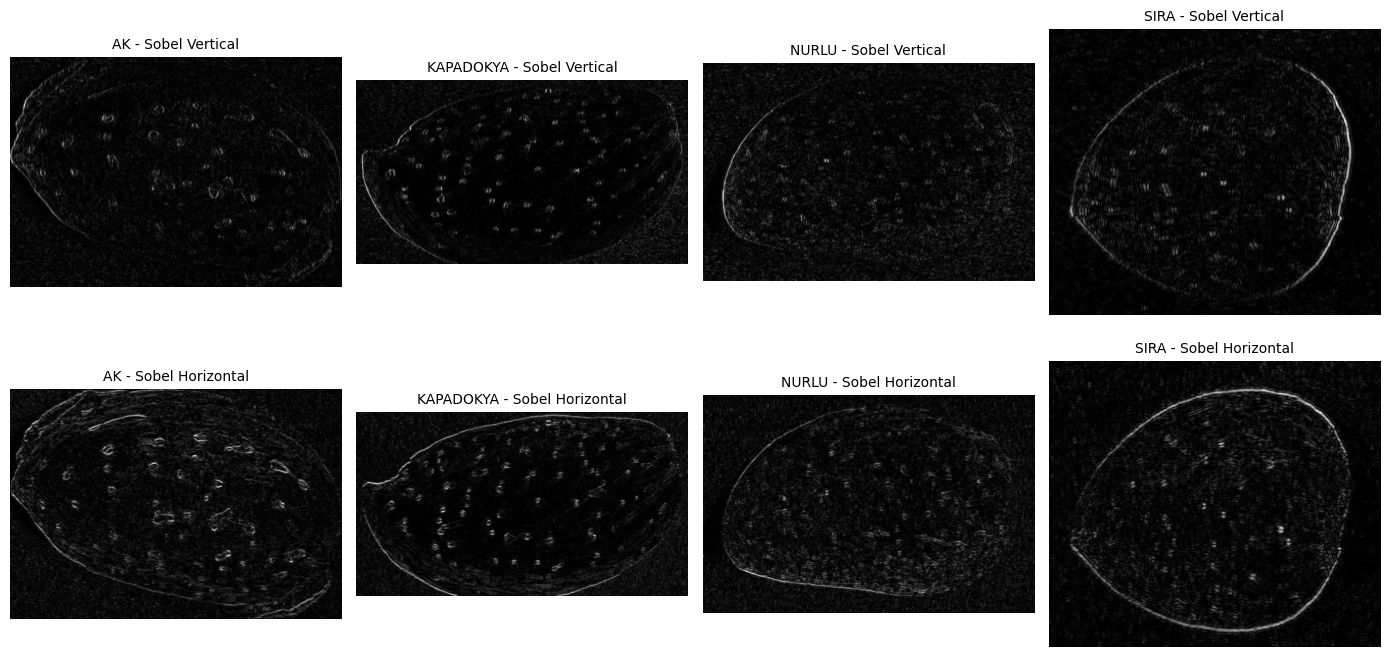

In [38]:
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.ndimage import convolve

# Definición de los filtros Sobel
h_sobelv = np.array([[1, 0, -1],
                     [2, 0, -2],
                     [1, 0, -1]])

h_sobelh = np.array([[1, 2, 1],
                     [0, 0, 0],
                     [-1, -2, -1]])


# Crear figura y ejes para la grilla 2x4 (vertical y horizontal)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.reshape(2, 4)

for col, (path, nombre) in enumerate(tipos_almendras):
    imagenes = os.listdir(path)[:1]  # Tomar solo la primera imagen
    img_path = os.path.join(path, imagenes[0])
    img = plt.imread(img_path)

    # Convertir a escala de grises
    if img.ndim == 3:
        gray = np.mean(img[:, :, :3], axis=2)
    else:
        gray = img

    # Aplicar Sobel vertical y horizontal
    sobel_v = convolve(gray.astype(float), h_sobelv)
    sobel_h = convolve(gray.astype(float), h_sobelh)

    # Mostrar bordes verticales
    axes[0, col].imshow(np.abs(sobel_v), cmap='gray')
    axes[0, col].axis('off')
    axes[0, col].set_title(f'{nombre} - Sobel Vertical', fontsize=10)

    # Mostrar bordes horizontales
    axes[1, col].imshow(np.abs(sobel_h), cmap='gray')
    axes[1, col].axis('off')
    axes[1, col].set_title(f'{nombre} - Sobel Horizontal', fontsize=10)

plt.tight_layout()
plt.show()

# Para combinación de bordes (opcional):
# sobel_comb = np.abs(sobel_v) + np.abs(sobel_h)
# sobel_mag = np.sqrt(sobel_v**2 + sobel_h**2)